# Propensity Arena Pipeline: Multi-Model Selection, Tuning & Calibration

This notebook implements a **production-grade, end-to-end ML pipeline** to predict the probability (propensity score) of an HCP prescribing Pfizer.

### Pipeline Architecture
1. **Data Loading & Filtering** — Focus on high-potential B/C segments
2. **Target Definition & Anti-Leakage** — Broad target + automatic correlation audit
3. **Dimensionality Reduction** — Top-N feature selection to prevent overfitting
4. **The Arena** — 4 state-of-the-art gradient boosting models compete head-to-head
5. **Optuna Hyperparameter Optimization** — Bayesian search on the winning algorithm
6. **Probability Calibration** — Isotonic calibration for trustworthy propensity scores
7. **Glass-Box Explainability** — SHAP global + local reason codes per HCP

### Why This Matters for Business
- **No algorithm bias**: We don't pre-select a model — the data decides which algorithm wins.
- **Calibrated probabilities**: Stakeholders can trust that a 30% score truly means ~30% likelihood.
- **Transparent decisions**: Every prediction comes with its top 5 driving factors.

In [1]:
# =====================================================================
# BLOCK 1: Imports and Environment Setup
# =====================================================================
# WHY: A clean, reproducible environment is the foundation of any
# trustworthy ML pipeline. We import all dependencies upfront so
# failures surface immediately, not halfway through a 30-minute run.
# =====================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import optuna
import shap
import matplotlib.pyplot as plt
import joblib
import warnings
import re
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, average_precision_score,
    precision_recall_curve, roc_curve, make_scorer
)
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Paths ---
# Data lives in the shared Xgboost_probabilities/data folder.
# We read from there directly to avoid data duplication.
DATA_DIR = Path("../Xgboost_probabilities/data")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Compatibility Patch for scikit-learn 1.6+ and XGBoost 2.0.x ---
# XGBoost's sklearn wrapper sometimes doesn't expose the right tags
# for CalibratedClassifierCV. This patch fixes that.
class PatchedXGBClassifier(xgb.XGBClassifier):
    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"
        return tags

# Similarly patch LightGBM if needed
class PatchedLGBMClassifier(lgb.LGBMClassifier):
    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"
        return tags

# CatBoost patch
class PatchedCatBoostClassifier(cb.CatBoostClassifier):
    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"
        return tags

print(" All imports successful.")
print(f"   XGBoost:  {xgb.__version__}")
print(f"   LightGBM: {lgb.__version__}")
print(f"   CatBoost: {cb.__version__}")
print(f"   Optuna:   {optuna.__version__}")
print(f"   SHAP:     {shap.__version__}")

 All imports successful.
   XGBoost:  2.0.3
   LightGBM: 4.6.0
   CatBoost: 1.2.10
   Optuna:   4.7.0
   SHAP:     0.49.1


In [2]:
# =====================================================================
# BLOCK 2: Data Loading & Filtering (Isolating Segments B & C)
# =====================================================================
# WHY: We focus exclusively on the B/C segment because these are the
# high-potential HCPs where propensity modeling adds the most business
# value. Segment A HCPs are already well-characterized.
# =====================================================================

print("Loading data...")

# Read the feature matrix (all HCPs) and the segment labels
features = pd.read_parquet(DATA_DIR / 'hcp_feature_matrix.parquet')
labels   = pd.read_csv(DATA_DIR / 'test_predictions_binary_segA_vs_segBC_with_hcp_id.csv')

# Ensure consistent ID types for the merge
features['NUEVO_ID'] = features['NUEVO_ID'].astype(str)
labels['NUEVO_ID']   = labels['NUEVO_ID'].astype(str)

# Inner join: only keep HCPs that exist in both datasets
df = features.merge(labels, on='NUEVO_ID', how='inner', suffixes=('', '_lbl'))

# Filter to high-potential segments (B and C only)
df = df[df['pred_binary_label'] == 'SEG_BC'].copy().reset_index(drop=True)

print(f"Dataset loaded. Shape after B/C filter: {df.shape}")
print(f"   Total HCPs in B/C segment: {len(df)}")
print(f"   Total features available:   {df.shape[1]}")

Loading data...
Dataset loaded. Shape after B/C filter: (633, 726)
   Total HCPs in B/C segment: 633
   Total features available:   726


In [3]:
# =====================================================================
# BLOCK 3: Target Definition & Anti-Leakage Protection
# =====================================================================
# WHY: Data leakage is the #1 silent killer of ML models in production.
# If a feature directly encodes the target (e.g., "has_prescribed_brand1"),
# the model will appear perfect in training but fail catastrophically
# on new data. We implement a TWO-LAYER defense:
#   Layer 1: Explicit drop of known brand/metadata columns
#   Layer 2: Automated Pearson correlation audit (threshold > 0.90)
# =====================================================================

# --- Target Definition ---
# The target captures whether an HCP has EVER prescribed the Pfizer brand.
# This is the best proxy for "propensity to prescribe" given our data.
TARGET_COL = 'propensity_target'
df[TARGET_COL] = (df['BRAND1_TRX__max'] > 0).astype(int)

pos_count = df[TARGET_COL].sum()
neg_count = len(df) - pos_count
print(f"Target Distribution:")
print(f"  Negative (0): {neg_count}")
print(f"  Positive (1): {pos_count}")
print(f"  Positive prevalence: {pos_count / len(df) * 100:.2f}%\n")

# Save HCP IDs for final output (before dropping them from features)
hcp_ids = df['NUEVO_ID'].copy()

# --- LAYER 1: Explicit Leakage Prevention ---
# Drop ALL brand-related columns (they directly encode the target)
brand_cols = [c for c in df.columns if 'BRAND1_' in c]

# Drop metadata/label columns that would leak segment or model info
metadata_cols = [
    'ATSEG_HCP', 'IS_LABELED_HCP', 'HCP_FOLD', 'n_rows',
    'NUEVO_ID', 'NUEVO_ID.1', 'true_original_label', 'true_original_encoded',
    'true_binary_label', 'true_binary_encoded', 'prob_SEG_A', 'prob_SEG_BC',
    'pred_binary_label', 'pred_binary_encoded', 'decision_threshold',
    'hcp_fold', 'model_name', 'true_label_encoded', TARGET_COL
]
# Also drop any columns that came from the labels merge (suffix '_lbl')
metadata_cols += [c for c in df.columns if c.endswith('_lbl')]

cols_to_drop = list(set(brand_cols + metadata_cols))
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

X = df.drop(columns=cols_to_drop)
X = X.select_dtypes(include=[np.number])  # Keep only numeric features
y = df[TARGET_COL]

print(f"[LAYER 1] Dropped {len(cols_to_drop)} known leaky/metadata columns.")
print(f"          Remaining features: {X.shape[1]}")

# Fix invalid column names (XGBoost/LightGBM don't allow [, ], <)
X.columns = [re.sub(r'[\[\]<]', '_', c) for c in X.columns]

# --- LAYER 2: Automated Correlation Audit ---
print("\n[LAYER 2] Scanning features for correlations > 0.90 with target...")
correlations = X.corrwith(y).abs()
leaky_features = correlations[correlations > 0.90].index.tolist()

if leaky_features:
    print(f"  WARNING: Found {len(leaky_features)} leaky features. Dropping:")
    for feat in leaky_features:
        print(f"     - {feat} (corr={correlations[feat]:.4f})")
    X = X.drop(columns=leaky_features)
else:
    print("  No hidden leakage detected.")

# --- Handle missing values ---
# Fill NaNs with 0 (appropriate for sparse medical claim features)
missing_before = X.isnull().sum().sum()
X = X.fillna(0)
print(f"\n[PREPROCESSING] Filled {missing_before} missing values with 0.")

# --- Train/Test Split ---
# Stratified split ensures both sets preserve the ~7.6% positive rate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Track which HCP IDs go to train vs test
train_idx = X_train.index
test_idx  = X_test.index
hcp_ids_test = hcp_ids.loc[test_idx].reset_index(drop=True)

print(f"\nData ready.")
print(f"   Train: {X_train.shape} | Positive: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Test:  {X_test.shape}  | Positive: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Target Distribution:
  Negative (0): 585
  Positive (1): 48
  Positive prevalence: 7.58%

[LAYER 1] Dropped 104 known leaky/metadata columns.
          Remaining features: 623

[LAYER 2] Scanning features for correlations > 0.90 with target...
  No hidden leakage detected.

[PREPROCESSING] Filled 0 missing values with 0.

Data ready.
   Train: (506, 623) | Positive: 38 (7.5%)
   Test:  (127, 623)  | Positive: 10 (7.9%)


In [4]:
# =====================================================================
# BLOCK 4: Automated Feature Selection (Dimensionality Reduction)
# =====================================================================
# WHY: With ~624 features and only 633 samples, we're at high risk of
# overfitting. Feature selection reduces noise, speeds up training, and
# produces more interpretable models. We use a lightweight XGBoost
# estimator to rank features by importance, then keep the top 40.
# =====================================================================

MAX_FEATURES = 40  # Balances signal vs. overfitting for this sample size

print(f"Selecting top {MAX_FEATURES} features to prevent overfitting...")

# Use a quick XGBoost model to rank feature importance
fs_model = PatchedXGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0,
    n_estimators=100  # Fast, just for ranking
)
fs = SelectFromModel(fs_model, max_features=MAX_FEATURES, threshold=-np.inf)
fs.fit(X_train, y_train)

selected_features = X_train.columns[fs.get_support()].tolist()
X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

print(f"✅ Reduced feature space: {X_train.shape[1]} → {X_train_sel.shape[1]} features.")
print(f"\nSelected Features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")

Selecting top 40 features to prevent overfitting...
✅ Reduced feature space: 623 → 40 features.

Selected Features:
   1. UC_TRX__std
   2. ORAL_TRX__mean
   3. ORAL_TRX__max
   4. ORAL_TRX__last
   5. IL23_TRX__last
   6. BRAND2_TRX__max
   7. UC_NRX__std
   8. ORAL_NRX__mean
   9. IL23_NRX__max
  10. N_CLMBRAND3__mean
  11. N_CLMBRAND4__mean
  12. N_CLMOTHERS__std
  13. N_CLMBRAND4_NEW__std
  14. N_CLMBRAND3NEW_TO_BRAND__mean
  15. COPAY__mean
  16. DETAILS__mean
  17. DETAILS__std
  18. DETAILS__max
  19. UC_TRX_R4_16SUM__std
  20. UC_TRX_R4_16SUM__min
  21. ORAL_NBRX_R4_29SUM__max
  22. ORAL_NBRX_R4_29SUM__last
  23. BRAND2_T_GIDX__min
  24. ORAL_TRX__early4_mean
  25. N_CLMBRAND2_NEW__early4_mean
  26. IL23_NBRX_R4_29SUM__early4_mean
  27. UC_NRX__recent4_mean
  28. ORAL_NRX__recent4_mean
  29. IL23_TRX__nonzero_share
  30. ORAL_NRX__nonzero_share
  31. N_CLMOTHERS_NEW_TO_BRAND__nonzero_share
  32. DETAILS__nonzero_share
  33. IL23_NBRX_R4_29SUM__nonzero_share
  34. IL23_TRX__slop

In [5]:
# =====================================================================
# BLOCK 5: THE ARENA — Automated Model Selection
# =====================================================================
# WHY: Different algorithms have different inductive biases. XGBoost
# excels at structured tabular data, LightGBM handles large feature
# spaces efficiently, CatBoost is robust to overfitting, and
# HistGradientBoosting is scikit-learn native. Rather than guessing
# which is best, we let them COMPETE on this specific dataset.
#
# METRIC: Average Precision (PR-AUC) — the right metric for imbalanced
# data because it focuses on the positive class (our 7.6% prescribers)
# rather than being inflated by easy negatives like ROC-AUC can be.
# =====================================================================

# Calculate class imbalance weight for models that support it
pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Class imbalance ratio (scale_pos_weight): {pos_weight:.2f}\n")

# --- Define the 4 Competing Models ---
arena_models = {
    'XGBoost': PatchedXGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=pos_weight,
        eval_metric='aucpr',
        random_state=RANDOM_STATE,
        tree_method='hist',
        verbosity=0
    ),
    'LightGBM': PatchedLGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=pos_weight,
        random_state=RANDOM_STATE,
        verbose=-1
    ),
    'CatBoost': PatchedCatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        auto_class_weights='Balanced',
        random_state=RANDOM_STATE,
        verbose=0
    ),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=300,
        max_depth=6,
        learning_rate=0.05,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )
}

# --- Run the Arena: 5-Fold Stratified CV for each model ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
arena_results = {}

print("🏟️  THE ARENA — 4 Models Competing on PR-AUC (5-Fold CV)")
print("=" * 65)

for name, model in arena_models.items():
    print(f"\n  ⚔️  Training {name}...", end=" ")
    
    fold_scores = []
    for fold_idx, (tr_idx, val_idx) in enumerate(cv.split(X_train_sel, y_train)):
        X_tr, X_val = X_train_sel.iloc[tr_idx], X_train_sel.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        
        try:
            model_clone = model.__class__(**model.get_params())
            model_clone.fit(X_tr, y_tr)
            preds = model_clone.predict_proba(X_val)[:, 1]
            score = average_precision_score(y_val, preds)
            fold_scores.append(score)
        except Exception as e:
            print(f"\n     ⚠️  Fold {fold_idx+1} failed: {e}")
    
    mean_score = np.mean(fold_scores) if fold_scores else 0.0
    std_score  = np.std(fold_scores) if fold_scores else 0.0
    arena_results[name] = {
        'mean_prauc': mean_score,
        'std_prauc': std_score,
        'fold_scores': fold_scores
    }
    print(f"PR-AUC = {mean_score:.4f} ± {std_score:.4f}")

# --- Display Results Table ---
print("\n" + "=" * 65)
results_df = pd.DataFrame({
    'Model': list(arena_results.keys()),
    'Mean PR-AUC': [r['mean_prauc'] for r in arena_results.values()],
    'Std PR-AUC': [r['std_prauc'] for r in arena_results.values()]
}).sort_values('Mean PR-AUC', ascending=False).reset_index(drop=True)

print("\n📊 Arena Results (sorted by PR-AUC):")
print(results_df.to_string(index=False))

# --- Select the Winner ---
winner_name = results_df.iloc[0]['Model']
winner_score = results_df.iloc[0]['Mean PR-AUC']
print(f"\n🏆 WINNER: {winner_name} with PR-AUC = {winner_score:.4f}")

Class imbalance ratio (scale_pos_weight): 12.32

🏟️  THE ARENA — 4 Models Competing on PR-AUC (5-Fold CV)

  ⚔️  Training XGBoost... PR-AUC = 0.6798 ± 0.0816

  ⚔️  Training LightGBM... PR-AUC = 0.5699 ± 0.0555

  ⚔️  Training CatBoost... PR-AUC = 0.6771 ± 0.0550

  ⚔️  Training HistGradientBoosting... PR-AUC = 0.5979 ± 0.1091


📊 Arena Results (sorted by PR-AUC):
               Model  Mean PR-AUC  Std PR-AUC
             XGBoost     0.679844    0.081619
            CatBoost     0.677092    0.055041
HistGradientBoosting     0.597853    0.109079
            LightGBM     0.569936    0.055459

🏆 WINNER: XGBoost with PR-AUC = 0.6798


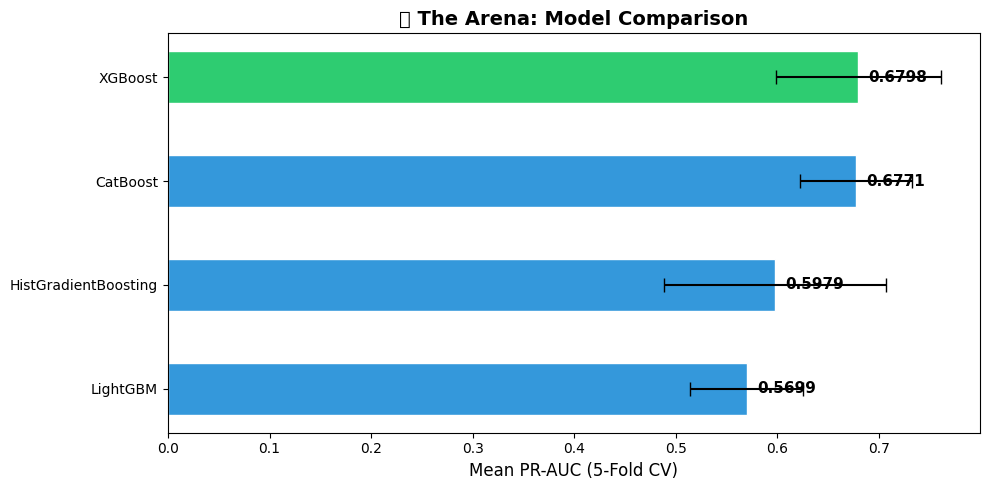


📈 Arena chart saved to output/arena_comparison.png


In [6]:
# --- Arena Visualization ---
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if name == winner_name else '#3498db' for name in results_df['Model']]
bars = ax.barh(results_df['Model'], results_df['Mean PR-AUC'], 
               xerr=results_df['Std PR-AUC'], color=colors, edgecolor='white',
               capsize=5, height=0.5)
ax.set_xlabel('Mean PR-AUC (5-Fold CV)', fontsize=12)
ax.set_title('🏟️ The Arena: Model Comparison', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels on bars
for bar, score in zip(bars, results_df['Mean PR-AUC']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arena_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n📈 Arena chart saved to {OUTPUT_DIR / 'arena_comparison.png'}")

In [7]:
# =====================================================================
# BLOCK 6: Optuna Hyperparameter Tuning on the Winner
# =====================================================================
# WHY: Default hyperparameters leave performance on the table. Optuna's
# Bayesian optimization intelligently explores the search space (unlike
# random/grid search), finding better configs in fewer trials. We run
# 30+ trials to balance thoroughness vs. compute time.
#
# IMPORTANT: The search space is DYNAMICALLY ADAPTED based on which
# algorithm won the arena. This is a key architectural decision — we
# don't tune a hardcoded model.
# =====================================================================

N_OPTUNA_TRIALS = 30

print(f"🔧 Tuning {winner_name} with Optuna ({N_OPTUNA_TRIALS} trials)...")
print(f"   Optimizing: PR-AUC (Average Precision) via 5-Fold CV\n")


def create_model_from_trial(trial, model_name):
    """
    Dynamically creates a model with Optuna-suggested hyperparameters
    based on the winning algorithm. Each algorithm has its own search
    space tailored to its most impactful parameters.
    """
    if model_name == 'XGBoost':
        return PatchedXGBClassifier(
            n_estimators=trial.suggest_int('n_estimators', 200, 1000),
            max_depth=trial.suggest_int('max_depth', 3, 9),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.15),
            subsample=trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            scale_pos_weight=pos_weight,
            eval_metric='aucpr',
            early_stopping_rounds=25,
            random_state=RANDOM_STATE,
            tree_method='hist',
            verbosity=0
        )
    
    elif model_name == 'LightGBM':
        return PatchedLGBMClassifier(
            n_estimators=trial.suggest_int('n_estimators', 200, 1000),
            num_leaves=trial.suggest_int('num_leaves', 15, 127),
            max_depth=trial.suggest_int('max_depth', 3, 9),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.15),
            subsample=trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_samples=trial.suggest_int('min_child_samples', 5, 50),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            scale_pos_weight=pos_weight,
            random_state=RANDOM_STATE,
            verbose=-1
        )
    
    elif model_name == 'CatBoost':
        return PatchedCatBoostClassifier(
            iterations=trial.suggest_int('iterations', 200, 1000),
            depth=trial.suggest_int('depth', 3, 9),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.15),
            l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
            bagging_temperature=trial.suggest_float('bagging_temperature', 0.0, 5.0),
            random_strength=trial.suggest_float('random_strength', 0.0, 5.0),
            auto_class_weights='Balanced',
            random_state=RANDOM_STATE,
            verbose=0
        )
    
    elif model_name == 'HistGradientBoosting':
        return HistGradientBoostingClassifier(
            max_iter=trial.suggest_int('max_iter', 200, 1000),
            max_depth=trial.suggest_int('max_depth', 3, 9),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.15),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 5, 50),
            max_leaf_nodes=trial.suggest_int('max_leaf_nodes', 15, 127),
            l2_regularization=trial.suggest_float('l2_regularization', 1e-4, 10.0, log=True),
            class_weight='balanced',
            random_state=RANDOM_STATE
        )
    
    raise ValueError(f"Unknown model: {model_name}")


def objective(trial):
    """
    Optuna objective: train the winning model with suggested hyperparameters,
    evaluate via 5-fold CV on PR-AUC, and return the mean score.
    """
    model = create_model_from_trial(trial, winner_name)
    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    
    for tr_idx, val_idx in cv_inner.split(X_train_sel, y_train):
        X_tr, X_val = X_train_sel.iloc[tr_idx], X_train_sel.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        
        try:
            # For models with early stopping, provide eval set
            if winner_name == 'XGBoost':
                model_clone = model.__class__(**model.get_params())
                model_clone.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            else:
                model_clone = model.__class__(**model.get_params())
                model_clone.fit(X_tr, y_tr)
            
            preds = model_clone.predict_proba(X_val)[:, 1]
            scores.append(average_precision_score(y_val, preds))
        except Exception:
            pass
    
    return np.mean(scores) if scores else 0.0


# --- Run Optuna ---
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

print(f"\n✅ Optuna Optimization Complete!")
print(f"   Best PR-AUC: {study.best_value:.4f}")
print(f"   Best Trial:  #{study.best_trial.number}")
print(f"\n   Best Hyperparameters:")
for k, v in study.best_params.items():
    print(f"     {k}: {v}")

🔧 Tuning XGBoost with Optuna (30 trials)...
   Optimizing: PR-AUC (Average Precision) via 5-Fold CV



  0%|          | 0/30 [00:00<?, ?it/s]


✅ Optuna Optimization Complete!
   Best PR-AUC: 0.7368
   Best Trial:  #6

   Best Hyperparameters:
     n_estimators: 697
     max_depth: 8
     learning_rate: 0.0658023854524495
     subsample: 0.5771109566460534
     colsample_bytree: 0.8639674365652075
     min_child_weight: 9
     reg_alpha: 0.8312038474962341
     reg_lambda: 0.0011291454280556747


In [8]:
# =====================================================================
# BLOCK 7: Probability Calibration (Isotonic)
# =====================================================================
# WHY: Raw model outputs are NOT true probabilities — a score of 0.30
# doesn't mean there's a 30% chance. Calibration using isotonic
# regression adjusts the output to be a TRUE probability estimate.
# This is CRITICAL for business trust: stakeholders need to know
# that scores map directly to real-world likelihoods.
#
# We evaluate calibration honesty via the Brier Score (lower = better),
# which measures the mean squared error of probability predictions.
# =====================================================================

print("🎯 Training tuned model and applying isotonic calibration...\n")

# --- Retrain the tuned model on the full training set ---
best_model = create_model_from_trial(
    type('Trial', (), {'suggest_int': lambda self, name, *a, **kw: study.best_params[name],
                        'suggest_float': lambda self, name, *a, **kw: study.best_params[name]})(),
    winner_name
)

# Remove early_stopping_rounds for final training (no validation set)
if hasattr(best_model, 'early_stopping_rounds'):
    best_model.set_params(early_stopping_rounds=None)

best_model.fit(X_train_sel, y_train)

# --- Evaluate BEFORE calibration ---
y_proba_uncal = best_model.predict_proba(X_test_sel)[:, 1]
prauc_uncal   = average_precision_score(y_test, y_proba_uncal)
rocauc_uncal  = roc_auc_score(y_test, y_proba_uncal)
brier_uncal   = brier_score_loss(y_test, y_proba_uncal)

print(f"BEFORE Calibration:")
print(f"  ROC-AUC:    {rocauc_uncal:.4f}")
print(f"  PR-AUC:     {prauc_uncal:.4f}")
print(f"  Brier Score: {brier_uncal:.4f}\n")

# --- Apply Isotonic Calibration ---
# CalibratedClassifierCV re-fits the model internally with CV, then
# applies isotonic regression to map raw scores → true probabilities.
calibrated_model = CalibratedClassifierCV(
    best_model, method='isotonic', cv=5
)
calibrated_model.fit(X_train_sel, y_train)

# --- Evaluate AFTER calibration ---
y_proba_cal = calibrated_model.predict_proba(X_test_sel)[:, 1]
prauc_cal   = average_precision_score(y_test, y_proba_cal)
rocauc_cal  = roc_auc_score(y_test, y_proba_cal)
brier_cal   = brier_score_loss(y_test, y_proba_cal)

print(f"AFTER Calibration (Isotonic):")
print(f"  ROC-AUC:    {rocauc_cal:.4f}")
print(f"  PR-AUC:     {prauc_cal:.4f}")
print(f"  Brier Score: {brier_cal:.4f}")

# --- Summary ---
print(f"\n📊 Calibration Impact:")
print(f"   Brier Score: {brier_uncal:.4f} → {brier_cal:.4f} ({'✅ Improved' if brier_cal < brier_uncal else '⚠️  Slightly worse'})")
print(f"   PR-AUC:     {prauc_uncal:.4f} → {prauc_cal:.4f}")

🎯 Training tuned model and applying isotonic calibration...

BEFORE Calibration:
  ROC-AUC:    0.9658
  PR-AUC:     0.8001
  Brier Score: 0.0358

AFTER Calibration (Isotonic):
  ROC-AUC:    0.9632
  PR-AUC:     0.7876
  Brier Score: 0.0355

📊 Calibration Impact:
   Brier Score: 0.0358 → 0.0355 (✅ Improved)
   PR-AUC:     0.8001 → 0.7876


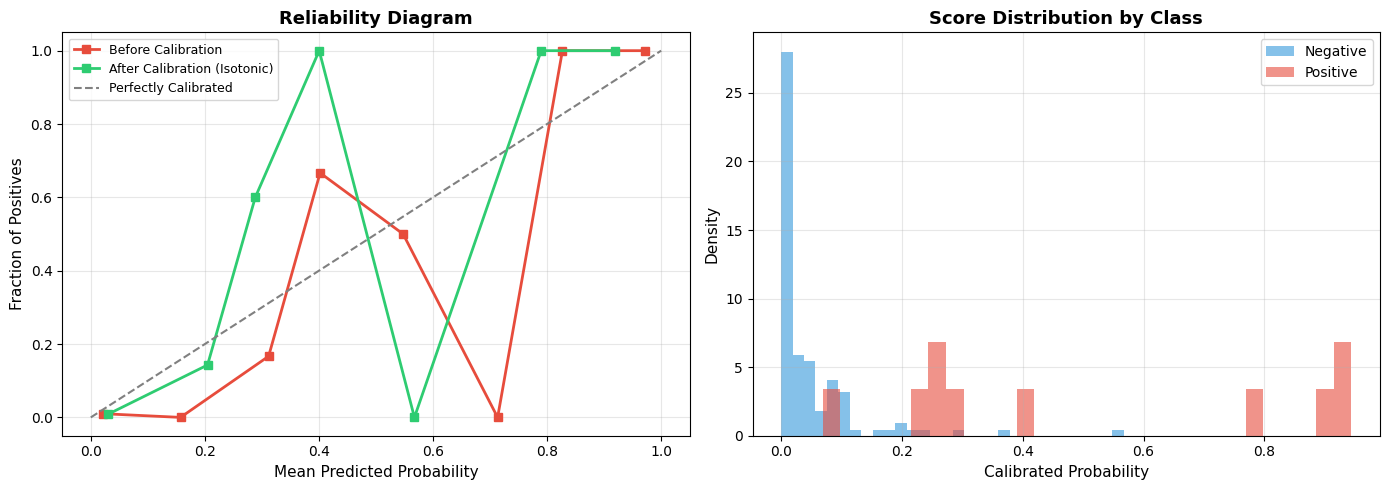

📈 Calibration analysis saved to output/calibration_analysis.png


In [9]:
# --- Reliability Diagram (Calibration Curve) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Calibration Curve
ax = axes[0]
for label, proba, color in [
    ('Before Calibration', y_proba_uncal, '#e74c3c'),
    ('After Calibration (Isotonic)', y_proba_cal, '#2ecc71')
]:
    fraction_pos, mean_predicted = calibration_curve(y_test, proba, n_bins=8)
    ax.plot(mean_predicted, fraction_pos, 's-', label=label, color=color, linewidth=2)

ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives', fontsize=11)
ax.set_title('Reliability Diagram', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: Score Distribution
ax = axes[1]
ax.hist(y_proba_cal[y_test == 0], bins=30, alpha=0.6, label='Negative', color='#3498db', density=True)
ax.hist(y_proba_cal[y_test == 1], bins=30, alpha=0.6, label='Positive', color='#e74c3c', density=True)
ax.set_xlabel('Calibrated Probability', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Score Distribution by Class', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'calibration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📈 Calibration analysis saved to {OUTPUT_DIR / 'calibration_analysis.png'}")

In [10]:
# =====================================================================
# BLOCK 8: SHAP Glass-Box Explainability & Final Export
# =====================================================================
# WHY: A black-box propensity score is useless if stakeholders can't
# understand WHY a particular HCP has a high/low score. SHAP provides:
#   - GLOBAL explanations: which features matter most overall
#   - LOCAL explanations: for each HCP, the top 5 reasons driving
#     their specific score ("reason codes")
#
# This is critical for:
#   - Regulatory compliance (explainable AI)
#   - Sales team trust ("why should I prioritize this HCP?")
#   - Model debugging (catching remaining leakage or artifacts)
# =====================================================================

print("🔍 Computing SHAP explanations...\n")

# --- Use TreeExplainer on the UNCALIBRATED model ---
# (SHAP TreeExplainer works directly on tree-based models, not on the
#  CalibratedClassifierCV wrapper. The feature importance ranking is
#  the same — calibration only transforms the output scale.)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sel)

# Handle different SHAP output formats depending on the model
# XGBoost/LightGBM return a single array, CatBoost may return a list
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Take the positive class

print(f"   SHAP values computed for {shap_values.shape[0]} test instances.")
print(f"   SHAP matrix shape: {shap_values.shape}")

🔍 Computing SHAP explanations...

   SHAP values computed for 127 test instances.
   SHAP matrix shape: (127, 40)



📊 Global Feature Importance (SHAP Beeswarm Plot):


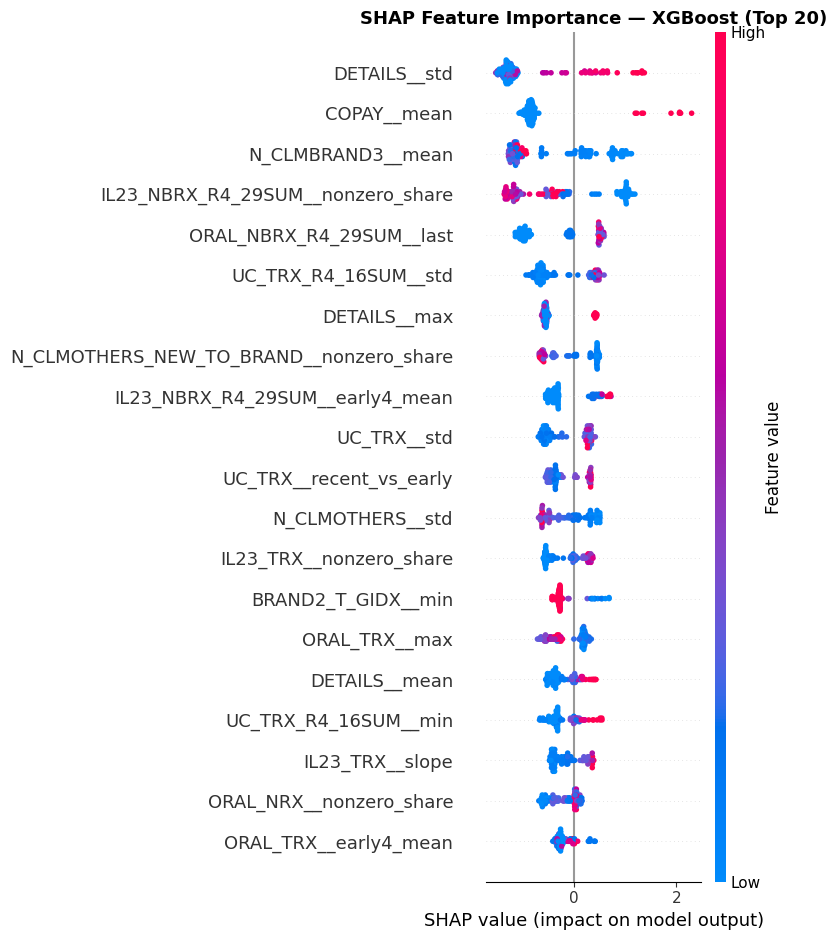

📈 SHAP global summary saved to output/shap_global_summary.png


In [11]:
# --- Global SHAP Summary Plot ---
print("\n📊 Global Feature Importance (SHAP Beeswarm Plot):")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sel, show=False, max_display=20)
plt.title(f'SHAP Feature Importance — {winner_name} (Top 20)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_global_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📈 SHAP global summary saved to {OUTPUT_DIR / 'shap_global_summary.png'}")

In [12]:
# --- Extract Top 5 Local Reason Codes per HCP ---

def extract_top_k_reasons(shap_vals_row, feature_values_row, feature_names, k=5):
    """
    For a single instance, extract the top-k most impactful features
    (by absolute SHAP value), along with their SHAP contribution and
    raw feature value.
    
    Returns:
        dict with keys: reason_1..reason_k, reason_1_shap..reason_k_shap,
                        reason_1_value..reason_k_value
    """
    # Sort by absolute SHAP value (most impactful first)
    sorted_idx = np.argsort(np.abs(shap_vals_row))[::-1][:k]
    
    result = {}
    for rank, idx in enumerate(sorted_idx, 1):
        result[f'reason_{rank}']       = feature_names[idx]
        result[f'reason_{rank}_shap']  = round(float(shap_vals_row[idx]), 6)
        result[f'reason_{rank}_value'] = round(float(feature_values_row[idx]), 4)
    
    return result


print("Extracting Top 5 Reason Codes for each test HCP...")

feature_names = X_test_sel.columns.tolist()
reason_records = []

for i in range(len(X_test_sel)):
    reasons = extract_top_k_reasons(
        shap_vals_row=shap_values[i],
        feature_values_row=X_test_sel.iloc[i].values,
        feature_names=feature_names,
        k=5
    )
    reason_records.append(reasons)

reasons_df = pd.DataFrame(reason_records)
print(f"✅ Extracted reason codes for {len(reasons_df)} HCPs.")

Extracting Top 5 Reason Codes for each test HCP...
✅ Extracted reason codes for 127 HCPs.


In [13]:
# --- Assemble Final Prediction DataFrame ---
final_df = pd.DataFrame({
    'NUEVO_ID': hcp_ids_test.values,
    'propensity_score': y_proba_cal,
    'actual_label': y_test.values
})

# Append reason codes
final_df = pd.concat([final_df.reset_index(drop=True), reasons_df], axis=1)

# Sort by propensity score (highest first = most likely prescribers)
final_df = final_df.sort_values('propensity_score', ascending=False).reset_index(drop=True)

print("\n📋 Final Prediction DataFrame (Top 10 HCPs):")
print("=" * 120)
display_cols = ['NUEVO_ID', 'propensity_score', 'actual_label',
                'reason_1', 'reason_1_shap', 'reason_2', 'reason_2_shap']
print(final_df[display_cols].head(10).to_string(index=False))

# --- Export to Parquet ---
output_path = OUTPUT_DIR / 'propensity_predictions_with_reasons.parquet'
final_df.to_parquet(output_path, index=False)
print(f"\n💾 Final predictions exported to: {output_path}")
print(f"   Shape: {final_df.shape}")
print(f"   Columns: {final_df.columns.tolist()}")


📋 Final Prediction DataFrame (Top 10 HCPs):
NUEVO_ID  propensity_score  actual_label          reason_1  reason_1_shap                          reason_2  reason_2_shap
   19875          0.944119             1       COPAY__mean       2.061871                 N_CLMBRAND3__mean      -1.018656
   14391          0.920000             1      DETAILS__std       1.243999                       COPAY__mean      -0.797604
   14142          0.891761             1      DETAILS__std      -1.246401                       COPAY__mean       1.229505
   15465          0.789657             1       COPAY__mean       1.897974                      DETAILS__std      -1.324690
   10106          0.567400             0 N_CLMBRAND3__mean      -0.988721                       COPAY__mean      -0.836345
   18932          0.400456             1      DETAILS__std       1.327378                 N_CLMBRAND3__mean      -0.991728
    8427          0.362627             0      DETAILS__std       1.248891 IL23_NBRX_R4_29SUM__

In [14]:
# =====================================================================
# FINAL SUMMARY
# =====================================================================

print("\n" + "=" * 65)
print("🏁 PIPELINE EXECUTION COMPLETE")
print("=" * 65)
print(f"")
print(f"🏟️  Arena Winner:          {winner_name}")
print(f"    Arena PR-AUC:          {winner_score:.4f}")
print(f"")
print(f"🔧 Optuna Best PR-AUC:     {study.best_value:.4f} ({N_OPTUNA_TRIALS} trials)")
print(f"")
print(f"📊 Final Test Metrics (Calibrated):")
print(f"    ROC-AUC:               {rocauc_cal:.4f}")
print(f"    PR-AUC:                {prauc_cal:.4f}")
print(f"    Brier Score:           {brier_cal:.4f}")
print(f"")
print(f"📁 Output Files:")
print(f"    Predictions:  {OUTPUT_DIR / 'propensity_predictions_with_reasons.parquet'}")
print(f"    Arena Chart:  {OUTPUT_DIR / 'arena_comparison.png'}")
print(f"    Calibration:  {OUTPUT_DIR / 'calibration_analysis.png'}")
print(f"    SHAP Summary: {OUTPUT_DIR / 'shap_global_summary.png'}")
print(f"")
print(f"✅ {len(final_df)} HCPs scored with Top 5 SHAP reason codes.")
print("=" * 65)


🏁 PIPELINE EXECUTION COMPLETE

🏟️  Arena Winner:          XGBoost
    Arena PR-AUC:          0.6798

🔧 Optuna Best PR-AUC:     0.7368 (30 trials)

📊 Final Test Metrics (Calibrated):
    ROC-AUC:               0.9632
    PR-AUC:                0.7876
    Brier Score:           0.0355

📁 Output Files:
    Predictions:  output/propensity_predictions_with_reasons.parquet
    Arena Chart:  output/arena_comparison.png
    Calibration:  output/calibration_analysis.png
    SHAP Summary: output/shap_global_summary.png

✅ 127 HCPs scored with Top 5 SHAP reason codes.
